# 03 — Feature Engineering

In this notebook, the cleaned question pairs were converted into reusable numeric features for downstream duplicate detection.

The feature space was expanded step by step with four complementary blocks:
- lexical and length-based signals;
- fuzzy string-matching signals;
- sparse similarity signals from BoW and TF-IDF;
- transformer-based semantic similarity signals from BERT embeddings.

The goal of this stage is not only to build the final feature table, but also to verify that the engineered signals provide meaningful class separation before modeling.

In [1]:
import sys
import torch
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from project_bootstrap import setup_project

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_CANDIDATE = NOTEBOOK_DIR if (NOTEBOOK_DIR / "project_bootstrap.py").exists() else NOTEBOOK_DIR.parent

if str(PROJECT_CANDIDATE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CANDIDATE))

PROJECT_ROOT = setup_project()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

%load_ext autoreload
%autoreload 2

from feature_engineering import (
    build_basic_pair_features,
    build_feature_table,
    build_fuzzy_features,
    build_sparse_similarity_features,
    build_transformer_similarity_features,
    get_feature_groups,
    get_numeric_feature_columns,
    load_preprocessed_dataset,
)

## 1. Load the preprocessed dataset

The feature engineering stage reuses the saved output of the preprocessing notebook.

This keeps the current analysis focused on pair-level numeric signals rather than repeating text cleanup. As a result, each feature block below can be interpreted as an additional layer of evidence about semantic or lexical similarity between the two questions.

In [3]:
df = load_preprocessed_dataset(PROJECT_ROOT)

preview_cols = [
    col for col in ["id", "question1", "question2", "q1_norm", "q2_norm", "q1_classic", "q2_classic", "is_duplicate"]
    if col in df.columns
]

print(f"Dataset shape: {df.shape}")
df[preview_cols].head()

Dataset shape: (323432, 10)


,id,question1,question2,q1_norm,q2_norm,q1_classic,q2_classic,is_duplicate
0,332278,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,the iliad and the odyssey in the greek culture,how do i prove that the pairs of three indepen...,iliad odyssey greek culture,prove pairs three independent variables also i...,0
1,196656,What is practical management and what is strat...,What are the practical aspects of strategic ma...,what is practical management and what is strat...,what are the practical aspects of strategic ma...,practical management strategic management,practical aspects strategic management,0
2,113125,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,how useful is makeuseof answers,is there any q a site that is not yahoo answer...,useful makeuseof answers,q site yahoo answers hate speech allowed,0
3,266232,Which is the best place to reside in India and...,Which ia the best place to visit in India?,which is the best place to reside in india and...,which ia the best place to visit in india,best place reside india,ia best place visit india,0
4,122738,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,why do so many people ask questions on quora t...,why do not many people posting questions on qu...,many people ask questions quora easily answere...,many people posting questions quora check goog...,1


In [4]:
from sklearn.metrics import roc_auc_score

def summarize_feature_group(feature_frame, *, target, feature_names):
    rows = []
    for feature in feature_names:
        if feature not in feature_frame.columns:
            continue
        score = feature_frame[feature].to_numpy()
        auc = roc_auc_score(target, score)
        auc = max(auc, 1 - auc)
        rows.append(
            {
                "feature": feature,
                "mean_duplicate": feature_frame.loc[target == 1, feature].mean(),
                "mean_non_duplicate": feature_frame.loc[target == 0, feature].mean(),
                "median_duplicate": feature_frame.loc[target == 1, feature].median(),
                "median_non_duplicate": feature_frame.loc[target == 0, feature].median(),
                "separation_auc": auc,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("separation_auc", ascending=False)
        .reset_index(drop=True)
    )

## 2. Basic lexical and length features

The first feature block was built directly from the normalized text.

This group captures the most interpretable signals in the dataset: question length, token overlap, exact matches, and shared bigrams. These features provide a strong baseline and make it easier to understand which surface-level text patterns are already informative for duplicate detection.

In [5]:
basic_features = build_basic_pair_features(df, q1_col="q1_norm", q2_col="q2_norm")

print(f"Basic feature frame shape: {basic_features.shape}")
basic_features.head()

Basic feature frame shape: (323432, 21)


,exact_match,q1_word_count,q2_word_count,q1_char_count,q2_char_count,word_count_diff,char_count_diff,mean_word_count,mean_char_count,first_word_eq,last_word_eq,common_word_count,common_non_stopword_count,total_unique_word_count,word_jaccard,non_stopword_jaccard,word_overlap_min,word_overlap_max,bigram_jaccard,word_count_ratio,char_count_ratio
0,0,9,14,46,80,5,34,11.5,63.0,0,0,1,0,19,0.052632,0.000000,0.142857,0.076923,0.000000,0.642857,0.575000
1,0,9,8,61,54,1,7,8.5,57.5,1,1,4,3,10,0.400000,0.750000,0.666667,0.500000,0.076923,0.888889,0.885246
2,0,5,16,31,76,11,45,10.5,53.5,0,0,2,1,17,0.117647,0.111111,0.400000,0.142857,0.000000,0.312500,0.407895
3,0,11,9,50,41,2,9,10.0,45.5,1,0,7,3,13,0.538462,0.500000,0.777778,0.636364,0.285714,0.818182,0.820000
4,0,31,12,157,68,19,89,21.5,112.5,1,0,9,5,32,0.281250,0.294118,0.750000,0.310345,0.108108,0.387097,0.433121


In [6]:
basic_features.describe().T.round(3).head(20)

,count,mean,std,min,25%,50%,75%,max
exact_match,323432.0,0.004,0.059,0.0,0.000,0.000,0.000,1.0
q1_word_count,323432.0,11.131,5.577,0.0,7.000,10.000,13.000,128.0
q2_word_count,323432.0,11.384,6.496,0.0,7.000,10.000,13.000,248.0
q1_char_count,323432.0,58.188,29.504,0.0,38.000,51.000,70.000,604.0
q2_char_count,323432.0,58.776,33.420,0.0,38.000,50.000,70.000,1141.0
word_count_diff,323432.0,3.777,4.975,0.0,1.000,2.000,5.000,233.0
char_count_diff,323432.0,19.876,25.175,0.0,4.000,11.000,25.000,1071.0
mean_word_count,323432.0,11.257,5.188,0.0,8.000,10.000,13.500,140.5
mean_char_count,323432.0,58.482,27.139,0.0,40.000,52.000,70.500,644.5
first_word_eq,323432.0,0.514,0.500,0.0,0.000,1.000,1.000,1.0


## 3. Visual analysis of lexical features

The following plots compare the main lexical features across duplicate and non-duplicate pairs.

Only the display range was clipped at the 99th percentile where needed, so the visualizations remain readable while the saved feature values stay unchanged. The purpose of this block is to verify whether simple overlap-based features already separate the target classes in a meaningful way.

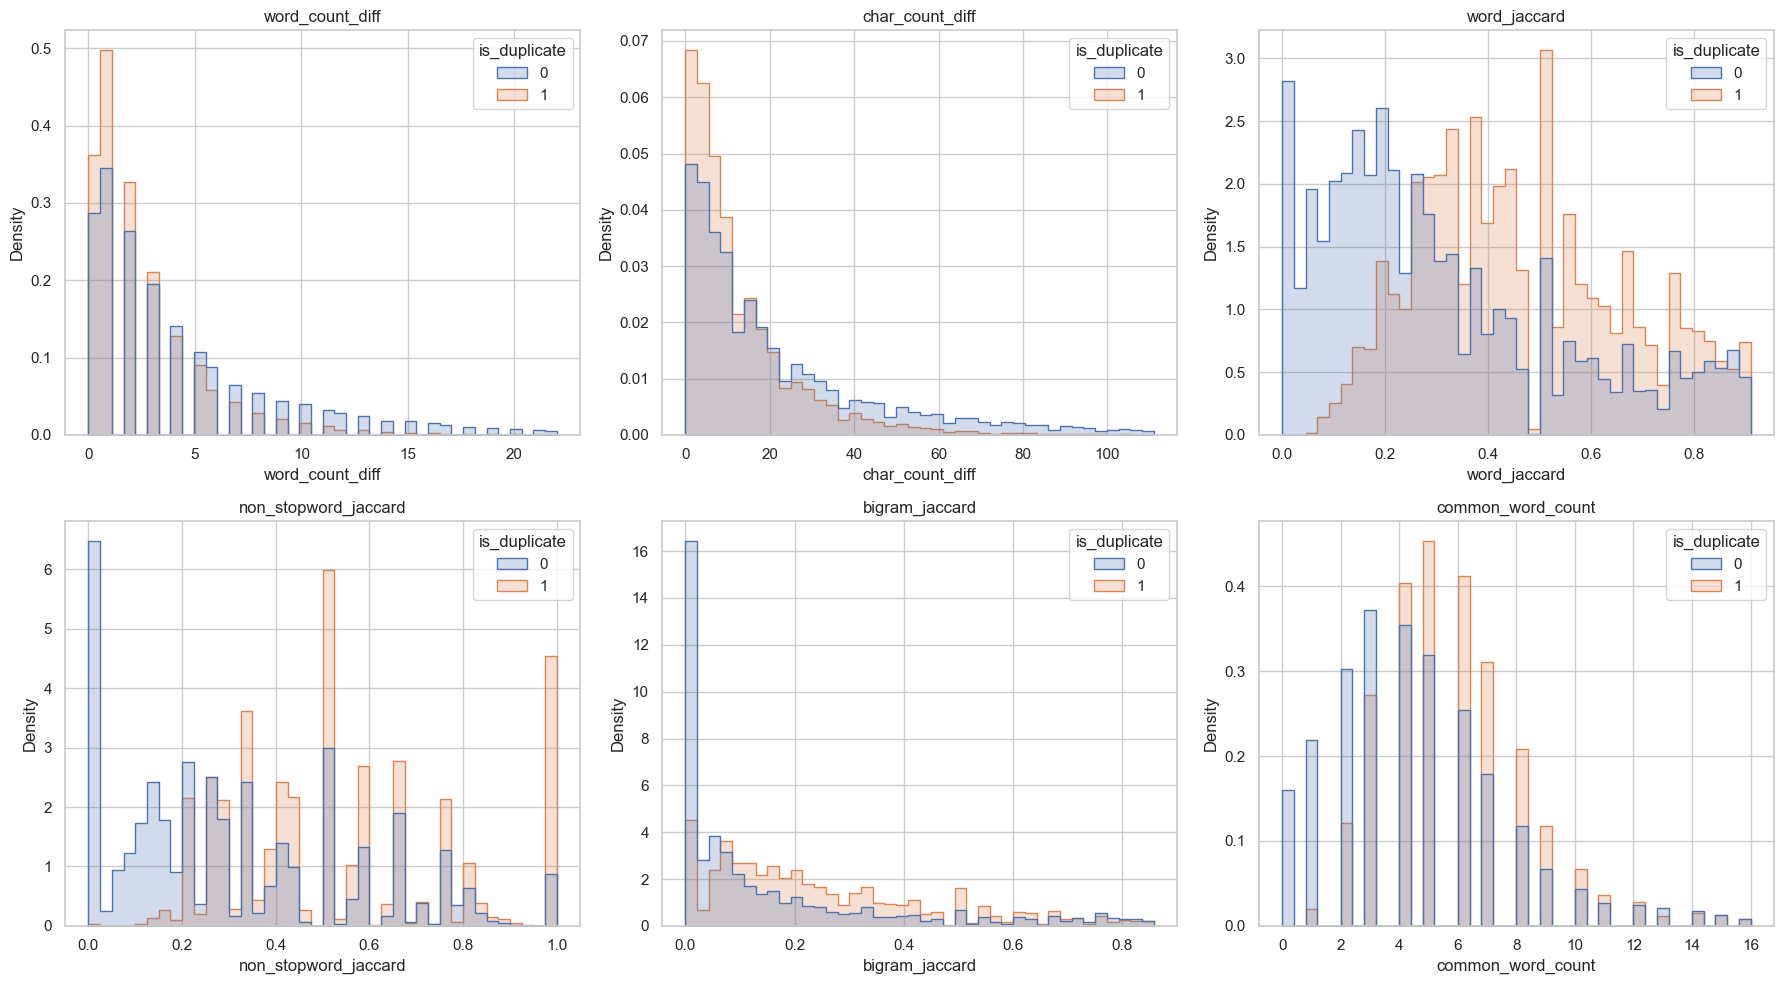

In [7]:
feature_groups = get_feature_groups()
target_col = "is_duplicate"

plot_df = pd.concat([df[[target_col]].reset_index(drop=True), basic_features], axis=1)
plot_sample = plot_df.sample(min(len(plot_df), 60000), random_state=42)

selected_basic = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
    "bigram_jaccard",
    "common_word_count",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_basic):
    upper = plot_sample[feature].quantile(0.99)
    view = plot_sample[plot_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

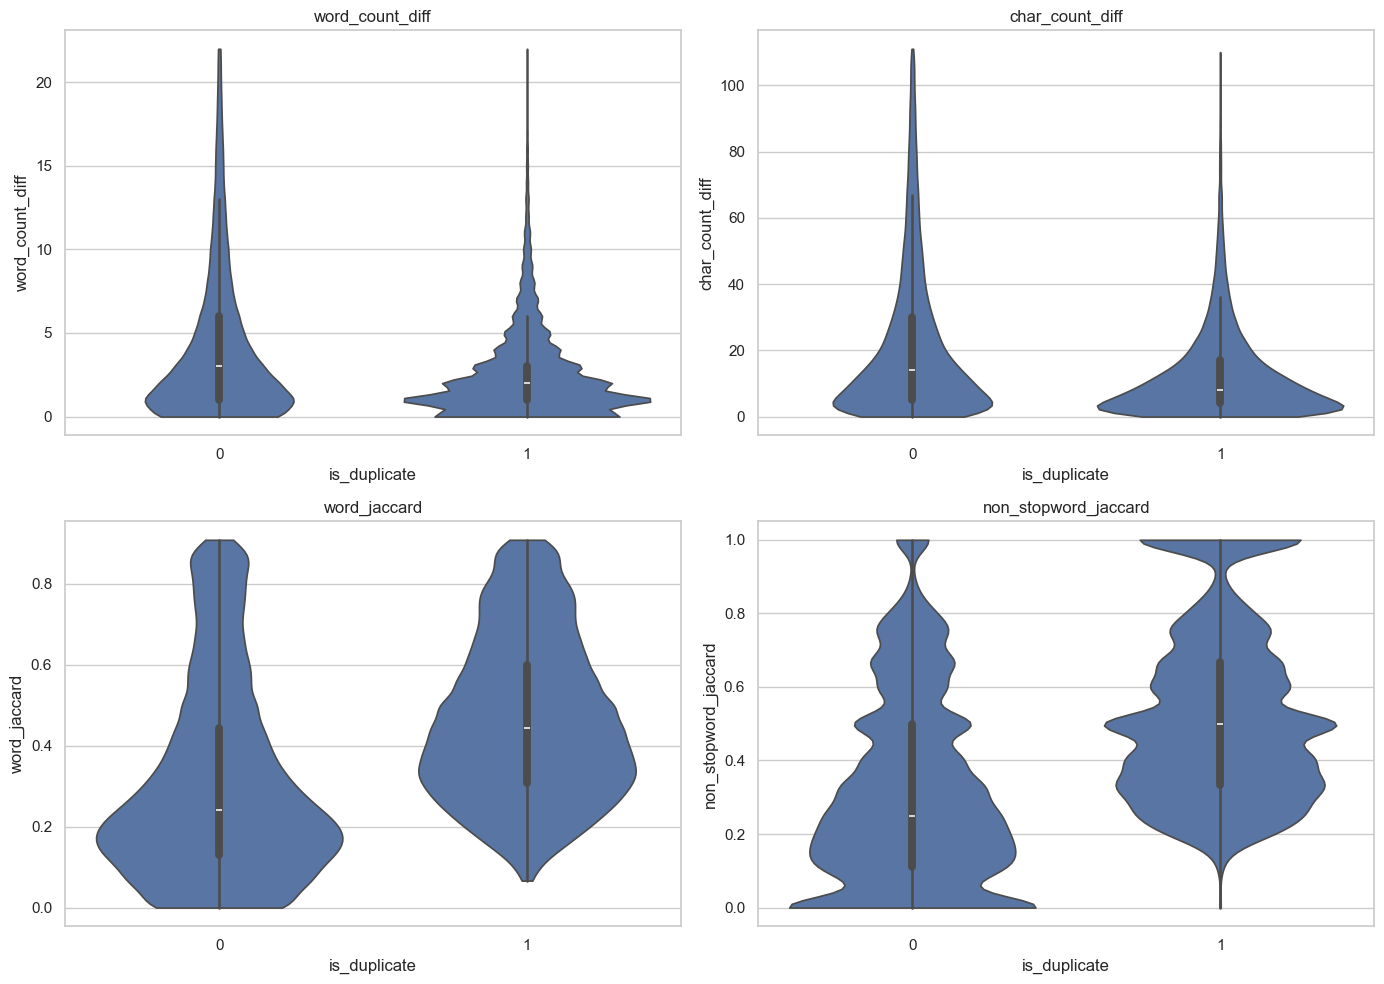

In [8]:
violin_basic = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, violin_basic):
    upper = plot_sample[feature].quantile(0.99)
    view = plot_sample[plot_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [9]:
basic_summary = summarize_feature_group(
    basic_features,
    target=df[target_col],
    feature_names=selected_basic,
)

basic_summary.round(4)

,feature,mean_duplicate,mean_non_duplicate,median_duplicate,median_non_duplicate,separation_auc
0,non_stopword_jaccard,0.5281,0.3079,0.5000,0.2500,0.7465
1,word_jaccard,0.4763,0.3095,0.4444,0.2414,0.7216
2,bigram_jaccard,0.2561,0.1581,0.2000,0.0667,0.6856
3,common_word_count,5.8883,4.5600,5.0000,4.0000,0.6541
4,char_count_diff,13.0047,23.8974,9.0000,14.0000,0.6188
5,word_count_diff,2.4562,4.5500,2.0000,3.0000,0.6115


**Interpretation.**

The lexical features show a clear and useful class shift. Duplicate pairs tend to have noticeably **higher overlap ratios** and **smaller length differences** than non-duplicates. Among the basic features, `non_stopword_jaccard` provides the strongest standalone separation in this block (AUC ≈ **0.75**), followed by `word_jaccard` (AUC ≈ **0.72**).

This means the dataset already contains a strong lexical similarity signal before any complex modeling is applied. At the same time, the overlap distributions still intersect, so lexical features alone are informative but not sufficient for perfect separation.

## 4. Fuzzy string-matching features

A second feature block was created with fuzzy matching scores.

These features complement the lexical overlap measures by capturing rephrasings, token reordering, and partial string matches. They are especially useful for question pairs that express the same intent with slightly different wording.

In [10]:
fuzzy_features = build_fuzzy_features(df, q1_col="q1_norm", q2_col="q2_norm")

print(f"Fuzzy feature frame shape: {fuzzy_features.shape}")
fuzzy_features.head()

Fuzzy feature frame shape: (323432, 5)


,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,longest_substr_ratio
0,34.920635,44.943820,41.269841,33.962264,0.108696
1,71.304348,68.292683,74.782609,90.909091,0.388889
2,33.644860,54.838710,35.514019,48.780488,0.258065
3,81.318681,87.804878,70.329670,87.671233,0.463415
4,48.000000,75.438596,47.111111,82.758621,0.294118


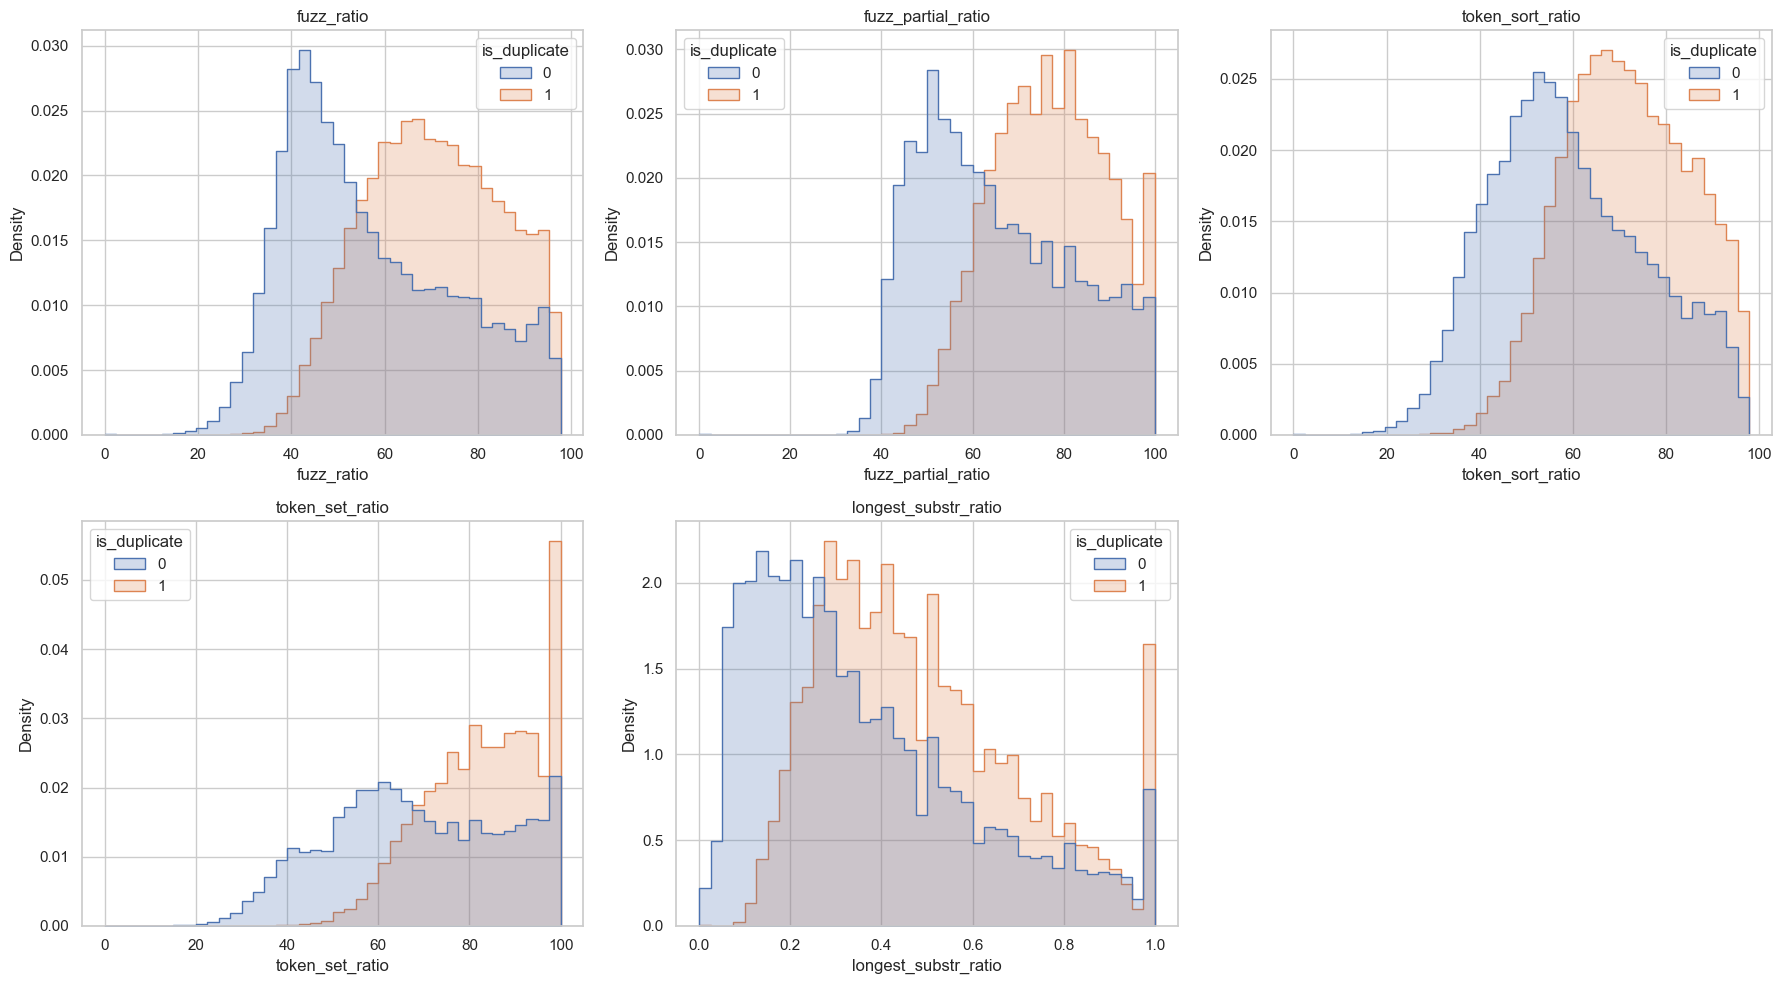

In [11]:
fuzzy_plot_df = pd.concat([df[[target_col]].reset_index(drop=True), fuzzy_features], axis=1)
fuzzy_sample = fuzzy_plot_df.sample(min(len(fuzzy_plot_df), 60000), random_state=42)

selected_fuzzy = [
    "fuzz_ratio",
    "fuzz_partial_ratio",
    "token_sort_ratio",
    "token_set_ratio",
    "longest_substr_ratio",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_fuzzy):
    upper = fuzzy_sample[feature].quantile(0.99)
    view = fuzzy_sample[fuzzy_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

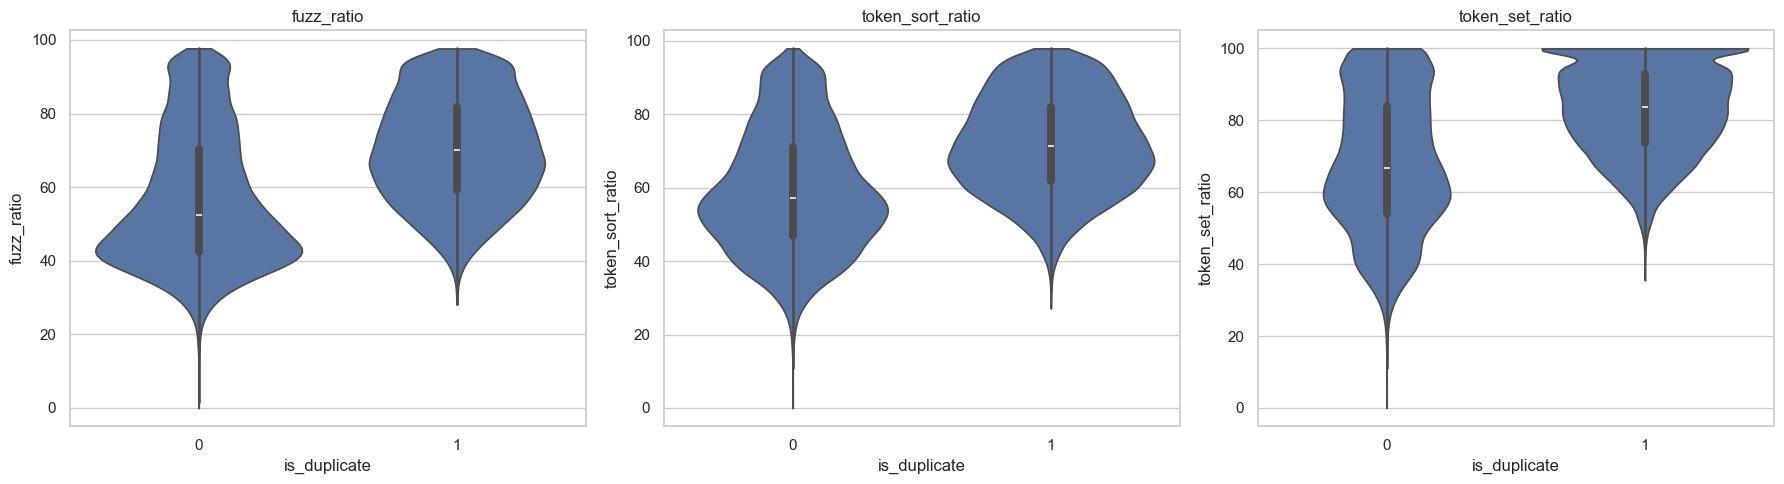

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ["fuzz_ratio", "token_sort_ratio", "token_set_ratio"]):
    upper = fuzzy_sample[feature].quantile(0.99)
    view = fuzzy_sample[fuzzy_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [13]:
fuzzy_summary = summarize_feature_group(
    fuzzy_features,
    target=df[target_col],
    feature_names=selected_fuzzy,
)

fuzzy_summary.round(4)

,feature,mean_duplicate,mean_non_duplicate,median_duplicate,median_non_duplicate,separation_auc
0,token_set_ratio,82.7384,67.8138,83.7838,66.6667,0.7321
1,fuzz_ratio,70.9359,56.8676,70.5882,52.5000,0.7287
2,token_sort_ratio,72.3210,59.2863,71.7949,57.1429,0.7259
3,fuzz_partial_ratio,76.9208,65.0950,76.9231,62.1849,0.7148
4,longest_substr_ratio,0.4849,0.3539,0.4444,0.2909,0.6820


**Interpretation.**

The fuzzy block confirms that duplicates are not only lexically overlapping, but also much closer at the string level. `token_set_ratio`, `fuzz_ratio`, and `token_sort_ratio` are the strongest features in this group, all reaching separation AUC values around **0.73**.

This is an important result for the project: many duplicate pairs are still recoverable even when the wording is rearranged or partially rewritten. In practice, this block adds robustness beyond simple token-count overlap.

## 5. Sparse text similarity features

The next block adds vector-space similarity signals based on count-driven text representations.

Bag of Words and TF-IDF were computed from the compact `q1_classic / q2_classic` text version, and cosine / Euclidean / Manhattan distances were derived for each pair. This extends the feature space from direct token overlap to broader document-level similarity.

In [14]:
bow_features = build_sparse_similarity_features(
    df,
    q1_col="q1_classic",
    q2_col="q2_classic",
    method="bow",
    prefix="bow",
)

tfidf_features = build_sparse_similarity_features(
    df,
    q1_col="q1_classic",
    q2_col="q2_classic",
    method="tfidf",
    prefix="tfidf",
)

sparse_features = pd.concat([bow_features, tfidf_features], axis=1)

print(f"Sparse similarity frame shape: {sparse_features.shape}")
sparse_features.head()

Sparse similarity frame shape: (323432, 6)


,bow_cosine,bow_euclidean,bow_manhattan,tfidf_cosine,tfidf_euclidean,tfidf_manhattan
0,0.000000,3.464102,10,0.000000,1.414214,4.068060
1,0.816497,1.414214,2,0.847734,0.551844,0.785760
2,0.267261,2.645751,7,0.219413,1.249470,3.375859
3,0.632456,2.236068,5,0.396429,1.098700,2.709021
4,0.347833,5.291503,28,0.176252,1.283548,6.882932


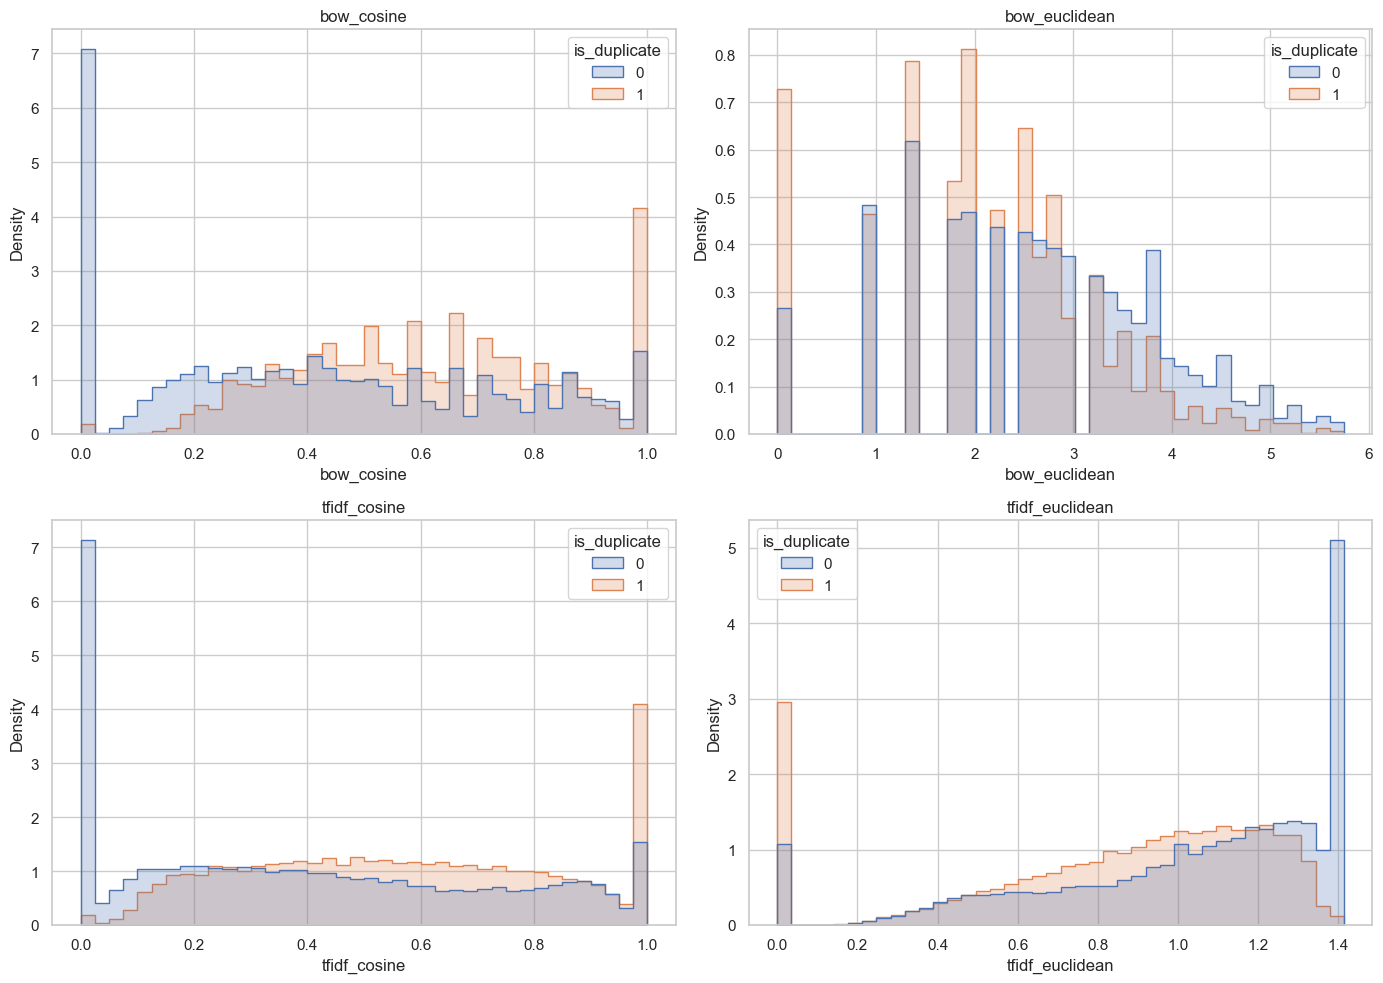

In [15]:
sparse_plot_df = pd.concat([df[[target_col]].reset_index(drop=True), sparse_features], axis=1)
sparse_sample = sparse_plot_df.sample(min(len(sparse_plot_df), 60000), random_state=42)

selected_sparse = [
    "bow_cosine",
    "bow_euclidean",
    "tfidf_cosine",
    "tfidf_euclidean",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_sparse):
    upper = sparse_sample[feature].quantile(0.99)
    view = sparse_sample[sparse_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

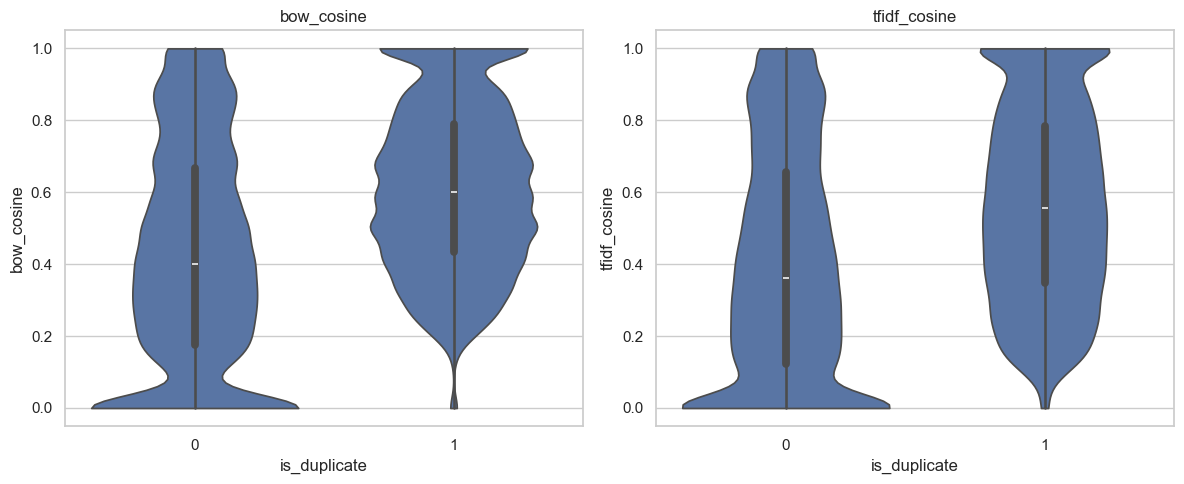

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, ["bow_cosine", "tfidf_cosine"]):
    upper = sparse_sample[feature].quantile(0.99)
    view = sparse_sample[sparse_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [17]:
sparse_summary = summarize_feature_group(
    sparse_features,
    target=df[target_col],
    feature_names=[
        "bow_cosine",
        "bow_euclidean",
        "bow_manhattan",
        "tfidf_cosine",
        "tfidf_euclidean",
        "tfidf_manhattan",
    ],
)

sparse_summary.round(4)

,feature,mean_duplicate,mean_non_duplicate,median_duplicate,median_non_duplicate,separation_auc
0,bow_cosine,0.6131,0.4188,0.6000,0.4000,0.6884
1,tfidf_cosine,0.5673,0.4001,0.5589,0.3604,0.6591
2,tfidf_euclidean,0.8461,1.0304,0.9388,1.1253,0.6566
3,tfidf_manhattan,2.2998,3.1079,2.2283,3.1180,0.6354
4,bow_euclidean,2.1847,2.7558,2.2361,2.6458,0.6250
5,bow_manhattan,6.0228,8.8034,5.0000,7.0000,0.6232


**Interpretation.**

The sparse-vector block adds a second independent view of similarity. Duplicate pairs have **higher cosine similarity** and **smaller vector distances** than non-duplicates for both BoW and TF-IDF.

Within this block, `bow_cosine` performs slightly better than `tfidf_cosine` on its own (AUC ≈ **0.69** vs **0.66**), while the distance features remain useful as complementary signals. This indicates that count-based and overlap-based features are aligned, but not fully redundant.

## 6. Transformer-based semantic similarity features

To cover the embedding-based approach from the assignment, an additional transformer block was prepared with BERT embeddings.

In this branch, the raw question text is used instead of the aggressively normalized variant, because transformer encoders benefit from preserving the original sentence structure. The output is intentionally kept compact: instead of saving all embedding dimensions, the notebook derives pair-level semantic features that are lightweight enough for Logistic Regression, Random Forest, and XGBoost.

In [18]:
RUN_BERT_FEATURES = True
BERT_MODEL_NAME = "bert-base-uncased"
BERT_BATCH_SIZE = 64
BERT_MAX_LENGTH = 64
BERT_POOLING = "mean"

bert_csv_path = PROCESSED_DIR / "bert_similarity_features.csv"
bert_parquet_path = PROCESSED_DIR / "bert_similarity_features.parquet"

if RUN_BERT_FEATURES:
    bert_features = build_transformer_similarity_features(
        df,
        q1_col="question1",
        q2_col="question2",
        model_name=BERT_MODEL_NAME,
        prefix="bert",
        batch_size=BERT_BATCH_SIZE,
        max_length=BERT_MAX_LENGTH,
        pooling=BERT_POOLING,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    bert_features.to_csv(bert_csv_path, index=False)
    try:
        bert_features.to_parquet(bert_parquet_path, index=False)
    except Exception:
        pass
    print(f"BERT feature frame shape: {bert_features.shape}")
    print(f"Saved CSV: {bert_csv_path.name}")
elif bert_csv_path.exists():
    bert_features = pd.read_csv(bert_csv_path)
    print(f"Loaded cached BERT features: {bert_features.shape}")
else:
    bert_features = None
    print(
        "BERT feature block is prepared but was not executed in this run. "
        "Set RUN_BERT_FEATURES = True in an environment with transformers access to build it."
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT similarity features:   0%|          | 0/5054 [00:00<?, ?batch/s]

BERT feature frame shape: (323432, 6)
Saved CSV: bert_similarity_features.csv


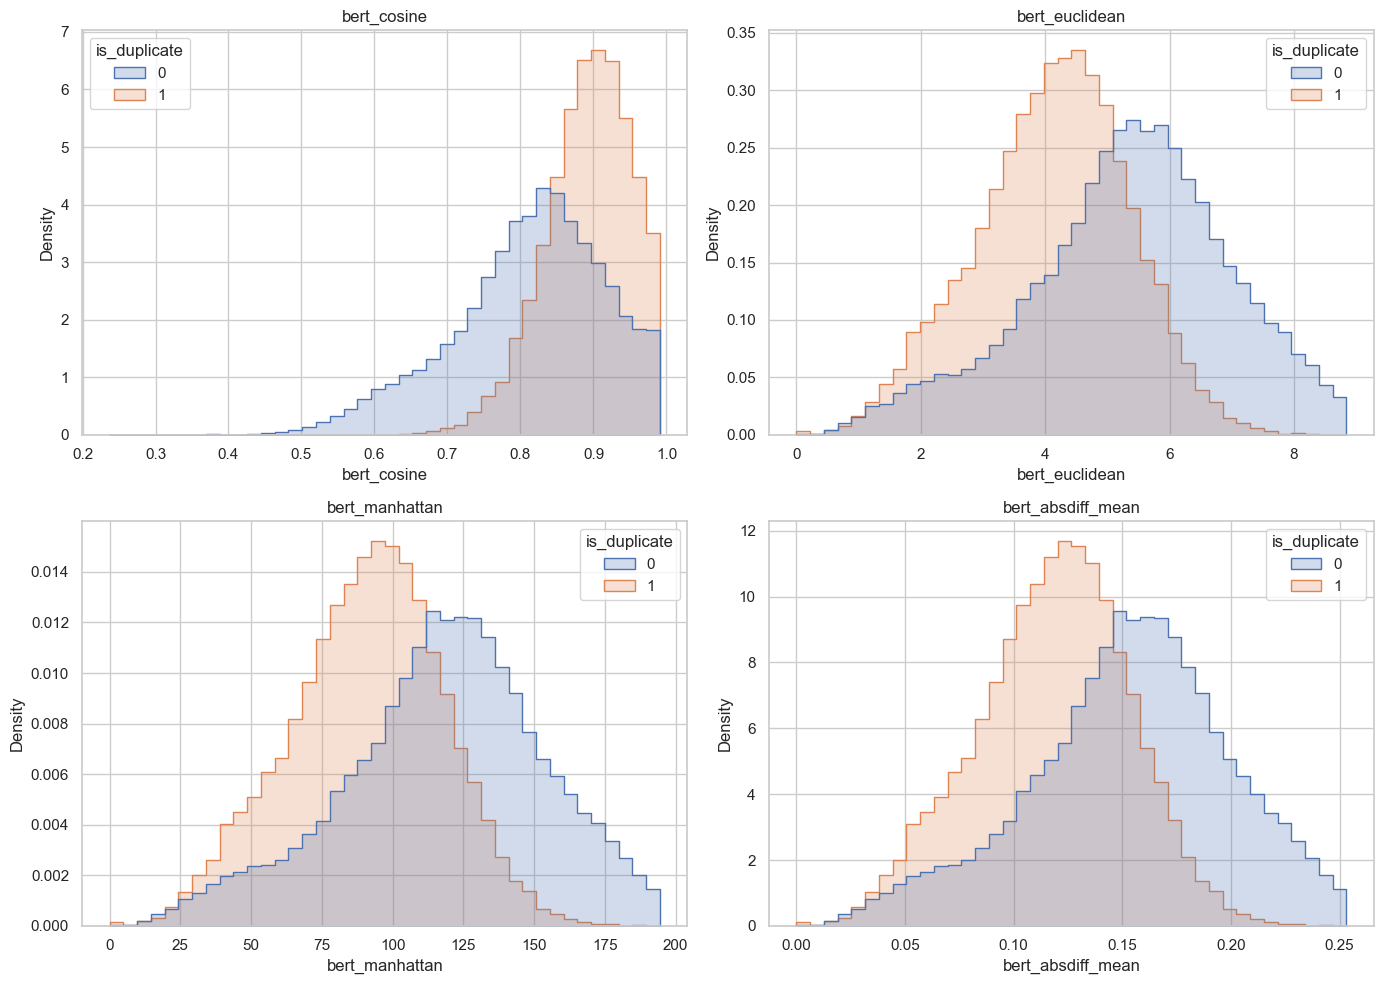

,feature,mean_duplicate,mean_non_duplicate,median_duplicate,median_non_duplicate,separation_auc
0,bert_cosine,0.892900,0.811200,0.898400,0.822800,0.7439
1,bert_manhattan,90.252502,119.129402,91.757103,120.805801,0.7427
2,bert_absdiff_mean,0.117500,0.155100,0.119500,0.157300,0.7427
3,bert_euclidean,4.105600,5.418100,4.174200,5.493900,0.7425
4,bert_dot,76.287804,68.757202,75.635902,68.743797,0.6970
5,bert_absdiff_max,0.590800,0.774600,0.555700,0.730900,0.6898


In [19]:
if bert_features is not None:
    bert_plot_df = pd.concat([df[[target_col]].reset_index(drop=True), bert_features], axis=1)
    bert_sample = bert_plot_df.sample(min(len(bert_plot_df), 60000), random_state=42)

    selected_bert = [
        "bert_cosine",
        "bert_euclidean",
        "bert_manhattan",
        "bert_absdiff_mean",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, feature in zip(axes, selected_bert):
        upper = bert_sample[feature].quantile(0.99)
        view = bert_sample[bert_sample[feature] <= upper].copy()
        sns.histplot(
            data=view,
            x=feature,
            hue=target_col,
            bins=40,
            stat="density",
            common_norm=False,
            element="step",
            ax=ax,
        )
        ax.set_title(feature)

    plt.tight_layout()
    plt.show()

    bert_summary = summarize_feature_group(
        bert_features,
        target=df[target_col],
        feature_names=[
            "bert_cosine",
            "bert_euclidean",
            "bert_manhattan",
            "bert_dot",
            "bert_absdiff_mean",
            "bert_absdiff_max",
        ],
    )

    display(bert_summary.round(4))
else:
    print("No BERT features are available yet for visualization.")

**Interpretation.**

The transformer-based semantic block was successfully computed and adds one of the strongest signal groups in the notebook. Duplicate pairs show **higher BERT cosine similarity and dot product**, while non-duplicate pairs have **larger embedding distances and larger absolute embedding differences**.

Among the semantic features, `bert_cosine` is the strongest standalone feature in this block with a separation AUC of approximately **0.744**. `bert_manhattan`, `bert_absdiff_mean`, and `bert_euclidean` perform almost identically, which shows that the semantic distance between the two questions is highly informative for the duplicate-detection task.

This is an important result for the project: BERT-based features perform **on par with the strongest lexical features** and outperform the fuzzy and sparse similarity blocks when considered individually. This suggests that contextual similarity captures useful information beyond surface word overlap and should be retained for downstream Logistic Regression, Random Forest, and XGBoost models.

## 7. Combine all engineered features

After the individual feature blocks were built and inspected, they were merged into one reusable feature table.

The resulting dataset can be passed directly to classical models and also serves as a compact summary of the work performed in this notebook.

In [20]:
feature_table = build_feature_table(df)

if bert_features is not None:
    feature_table = pd.concat([feature_table, bert_features.reset_index(drop=True)], axis=1)
    feature_table = feature_table.loc[:, ~feature_table.columns.duplicated()]

feature_csv_path = PROCESSED_DIR / "pair_similarity_features.csv"
feature_parquet_path = PROCESSED_DIR / "pair_similarity_features.parquet"

feature_table.to_csv(feature_csv_path, index=False)
try:
    feature_table.to_parquet(feature_parquet_path, index=False)
except Exception:
    pass

print(f"Feature table shape: {feature_table.shape}")
print(f"Saved CSV: {feature_csv_path.name}")
print(f"Saved Parquet: {feature_parquet_path.name} (if parquet support is available)")

feature_table.head()

Feature table shape: (323432, 40)
Saved CSV: pair_similarity_features.csv
Saved Parquet: pair_similarity_features.parquet (if parquet support is available)


,id,is_duplicate,exact_match,q1_word_count,q2_word_count,q1_char_count,q2_char_count,word_count_diff,char_count_diff,mean_word_count,mean_char_count,first_word_eq,last_word_eq,common_word_count,common_non_stopword_count,total_unique_word_count,word_jaccard,non_stopword_jaccard,word_overlap_min,word_overlap_max,bigram_jaccard,word_count_ratio,char_count_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,longest_substr_ratio,bow_cosine,bow_euclidean,bow_manhattan,tfidf_cosine,tfidf_euclidean,tfidf_manhattan,bert_cosine,bert_euclidean,bert_manhattan,bert_dot,bert_absdiff_mean,bert_absdiff_max
0,332278,0,0,9,14,46,80,5,34,11.5,63.0,0,0,1,0,19,0.052632,0.000000,0.142857,0.076923,0.000000,0.642857,0.575000,34.920635,44.943820,41.269841,33.962264,0.108696,0.000000,3.464102,10,0.000000,1.414214,4.068060,0.549825,9.286046,206.047302,52.656792,0.268291,1.064612
1,196656,0,0,9,8,61,54,1,7,8.5,57.5,1,1,4,3,10,0.400000,0.750000,0.666667,0.500000,0.076923,0.888889,0.885246,71.304348,68.292683,74.782609,90.909091,0.388889,0.816497,1.414214,2,0.847734,0.551844,0.785760,0.902288,4.273549,94.167023,83.933090,0.122613,0.552693
2,113125,0,0,5,16,31,76,11,45,10.5,53.5,0,0,2,1,17,0.117647,0.111111,0.400000,0.142857,0.000000,0.312500,0.407895,33.644860,54.838710,35.514019,48.780488,0.258065,0.267261,2.645751,7,0.219413,1.249470,3.375859,0.631046,7.695594,167.420776,50.610325,0.217996,1.016660
3,266232,0,0,11,9,50,41,2,9,10.0,45.5,1,0,7,3,13,0.538462,0.500000,0.777778,0.636364,0.285714,0.818182,0.820000,81.318681,87.804878,70.329670,87.671233,0.463415,0.632456,2.236068,5,0.396429,1.098700,2.709021,0.896967,4.149095,91.265923,74.868317,0.118836,0.511979
4,122738,1,0,31,12,157,68,19,89,21.5,112.5,1,0,9,5,32,0.281250,0.294118,0.750000,0.310345,0.108108,0.387097,0.433121,48.000000,75.438596,47.111111,82.758621,0.294118,0.347833,5.291503,28,0.176252,1.283548,6.882932,0.878029,4.412490,96.507629,69.366302,0.125661,0.687423


## 8. Correlation structure and class-level patterns

Once the final feature table is assembled, it is useful to inspect redundancy and complementarity across feature groups.

This step helps determine whether several features are effectively measuring the same property of the text pair, and whether the combined feature set still provides multiple distinct views of similarity.

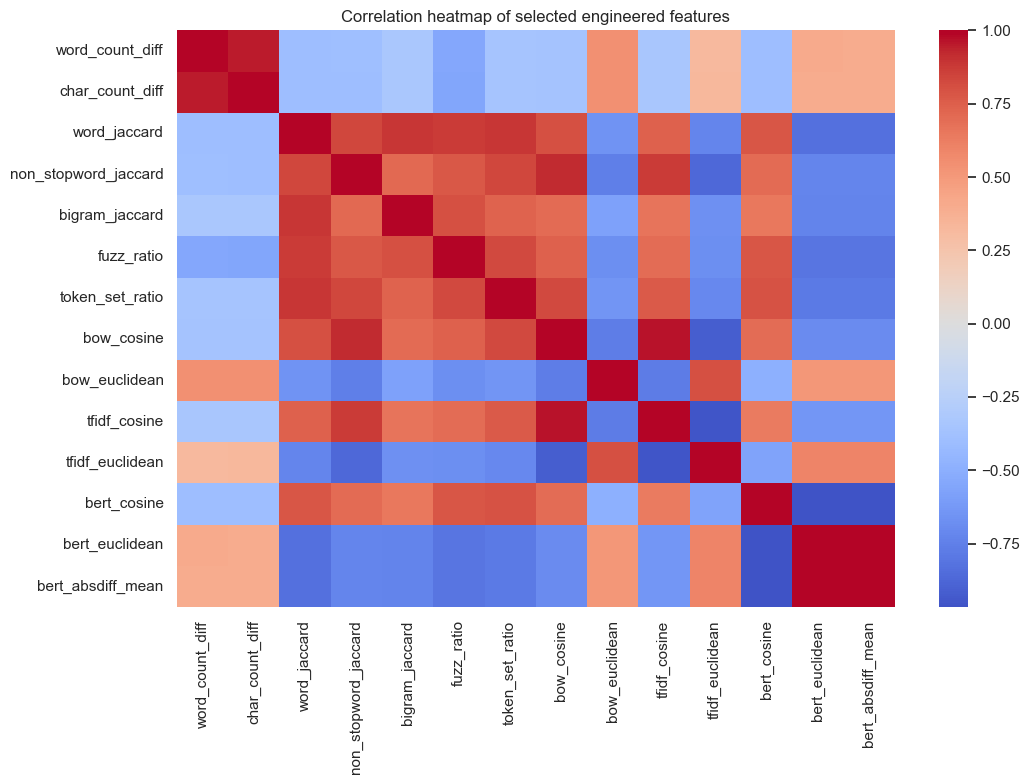

In [21]:
numeric_cols = get_numeric_feature_columns(feature_table)
corr_cols = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
    "bigram_jaccard",
    "fuzz_ratio",
    "token_set_ratio",
    "bow_cosine",
    "bow_euclidean",
    "tfidf_cosine",
    "tfidf_euclidean",
    "bert_cosine",
    "bert_euclidean",
    "bert_absdiff_mean",
]

corr_cols = [col for col in corr_cols if col in feature_table.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(feature_table[corr_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap of selected engineered features")
plt.tight_layout()
plt.show()

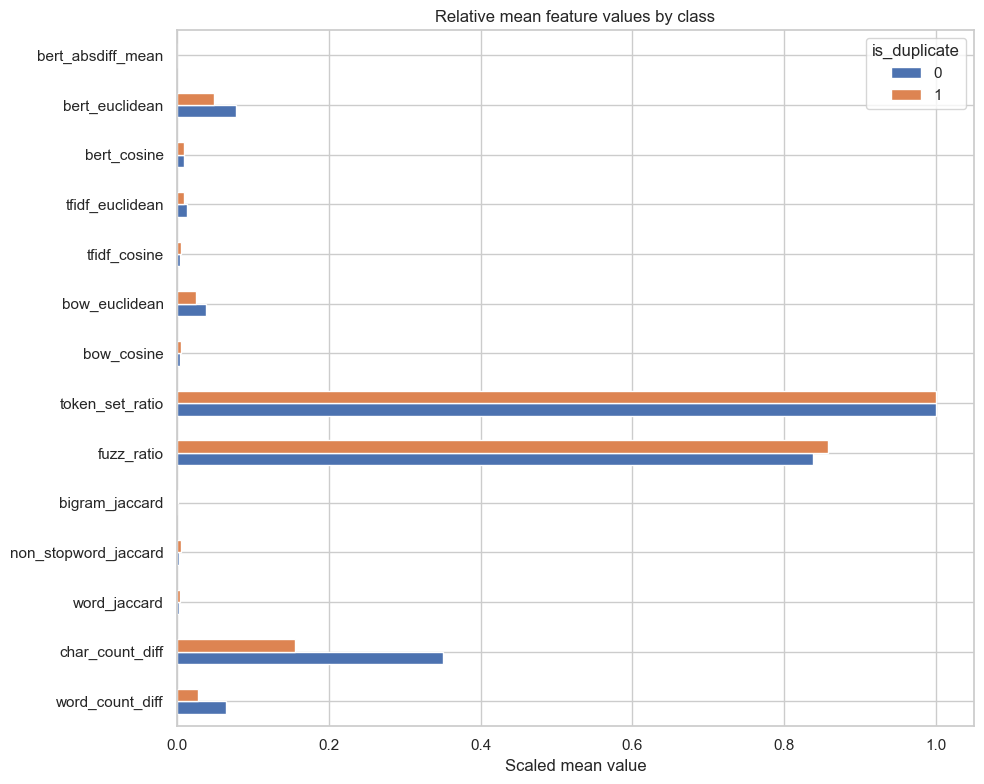

In [22]:
mean_by_class = feature_table.groupby("is_duplicate")[corr_cols].mean().T
scaled_mean_by_class = mean_by_class.copy()

for col in scaled_mean_by_class.columns:
    column = scaled_mean_by_class[col]
    col_min = column.min()
    col_max = column.max()
    if col_max > col_min:
        scaled_mean_by_class[col] = (column - col_min) / (col_max - col_min)

scaled_mean_by_class.plot(kind="barh", figsize=(10, 8))
plt.title("Relative mean feature values by class")
plt.xlabel("Scaled mean value")
plt.tight_layout()
plt.show()

**Interpretation.**

The correlation map shows that some feature families are strongly related, but not identical. The clearest examples are `word_count_diff` with `char_count_diff` (ρ ≈ **0.95**) and `bow_cosine` with `tfidf_cosine` (ρ ≈ **0.97**), which confirms that both pairs are measuring very similar properties.

At the same time, the feature blocks are not fully redundant. Overlap-based features, fuzzy scores, and vector-space distances still provide different magnitudes and ranking behaviour across the two classes. This supports keeping multiple feature families in the final table rather than relying on only one representation.

## 9. Pairplot and low-dimensional views of the engineered feature space

The final visual block projects the engineered features into a lower-dimensional space.

These views are not used for training directly. Instead, they provide a compact visual check of whether the combined feature space contains class structure that could be exploited later by downstream models.

In [23]:
RUN_PAIRPLOT = False

pairplot_features = [
    "word_jaccard",
    "non_stopword_jaccard",
    "fuzz_ratio",
    "token_set_ratio",
    "tfidf_cosine",
]

if RUN_PAIRPLOT:
    pairplot_sample = feature_table[["is_duplicate"] + pairplot_features].sample(
        min(len(feature_table), 2000),
        random_state=42,
    )
    sns.pairplot(pairplot_sample, hue="is_duplicate", corner=True, diag_kind="hist")
    plt.show()

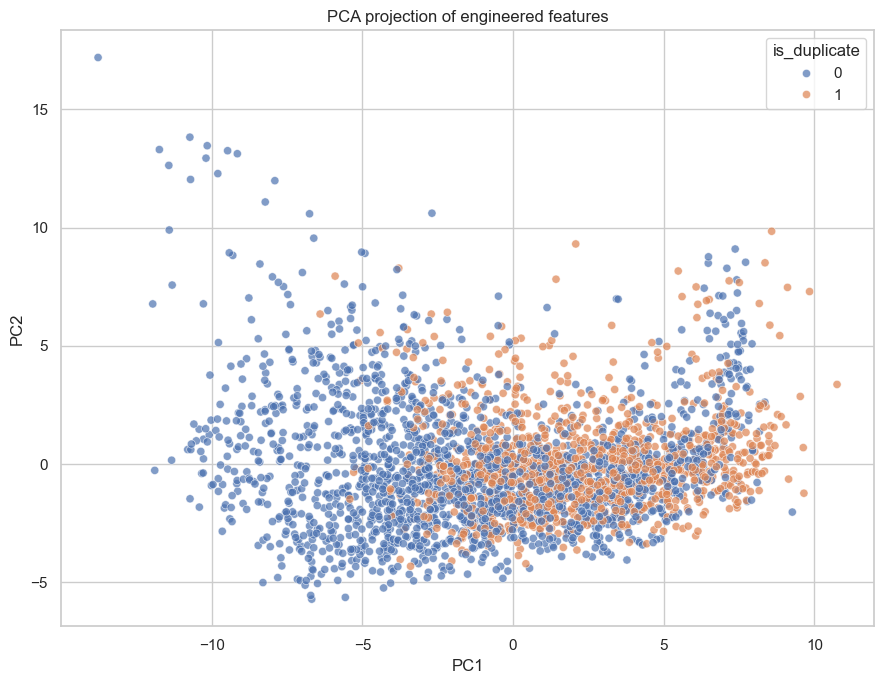

In [24]:
projection_features = [
    col for col in numeric_cols
    if col in feature_table.columns
]

projection_sample = feature_table[["is_duplicate"] + projection_features].sample(
    min(len(feature_table), 3000),
    random_state=42,
).reset_index(drop=True)

X_proj = projection_sample[projection_features].copy()
y_proj = projection_sample["is_duplicate"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proj)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["is_duplicate"] = y_proj.values

plt.figure(figsize=(9, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="is_duplicate", s=35, alpha=0.7)
plt.title("PCA projection of engineered features")
plt.tight_layout()
plt.show()

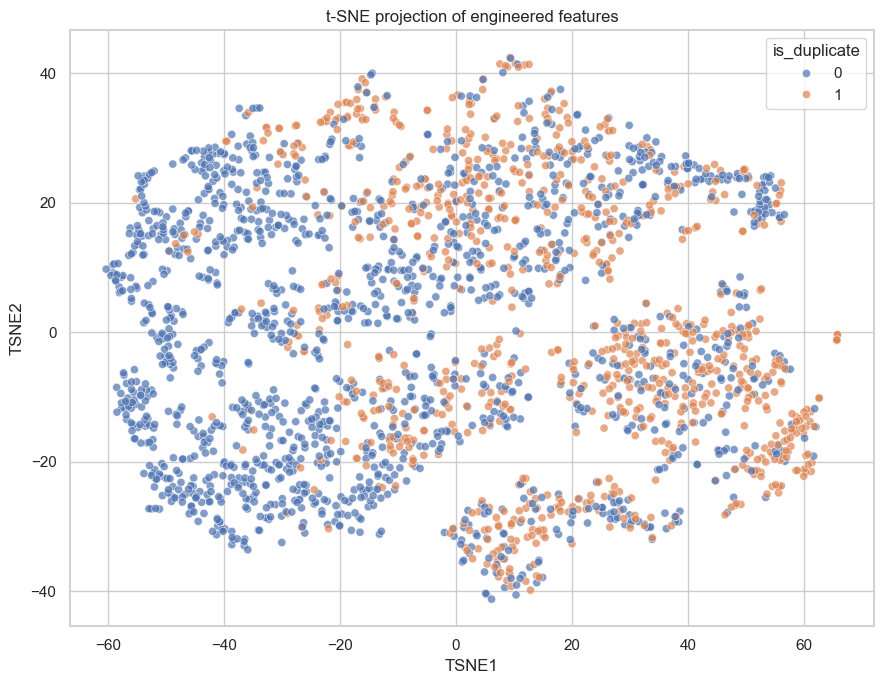

In [25]:
tsne_sample = feature_table[["is_duplicate"] + projection_features].sample(
    min(len(feature_table), 2500),
    random_state=42,
).reset_index(drop=True)

X_tsne = tsne_sample[projection_features].copy()
y_tsne = tsne_sample["is_duplicate"].copy()

scaler = StandardScaler()
X_tsne_scaled = scaler.fit_transform(X_tsne)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

X_tsne_2d = tsne.fit_transform(X_tsne_scaled)

tsne_df = pd.DataFrame(X_tsne_2d, columns=["TSNE1", "TSNE2"])
tsne_df["is_duplicate"] = y_tsne.values

plt.figure(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="is_duplicate", s=35, alpha=0.7)
plt.title("t-SNE projection of engineered features")
plt.tight_layout()
plt.show()

**Interpretation.**

The low-dimensional projections suggest that the engineered space contains a meaningful class structure, but not a perfectly clean split. This is the expected pattern for the Quora duplicate task: many examples are separable, yet a substantial overlap remains because semantic equivalence is more complex than surface-form similarity.

A useful side observation is that the first two PCA components retain a large share of the variance (about **70%** on the sampled data), which indicates that the feature table is structured rather than purely noisy. This is a good sign before moving to the modeling stage.

## 10. Feature engineering summary

This notebook transformed the preprocessed Quora question pairs into a reusable feature table for duplicate-question classification.

Main outcomes of the feature engineering stage:
- lexical and length-based signals were created from the normalized text;
- fuzzy matching scores were added to capture close rephrasings and token reordering;
- sparse BoW and TF-IDF similarities were computed to represent the pairs in vector space;
- BERT-based semantic similarity features were computed to capture contextual similarity beyond direct lexical overlap;
- class-wise plots and summary tables confirmed that duplicate pairs usually have higher overlap and similarity scores than non-duplicates across all major feature families;
- the strongest individual features came from the lexical and BERT-based blocks, while fuzzy and sparse features remained useful complementary signals;
- all engineered features were merged into one dataset that is ready for Logistic Regression, Random Forest, and XGBoost.

Overall, the notebook shows that the data was not only cleaned, but also translated into several complementary views of similarity: lexical, fuzzy, sparse-vector, and semantic. This substantially improves the information available to downstream models compared with using raw text alone.